In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Download the dataset using gdown
import gdown

# The Google Drive link you provided
file_url = "https://drive.google.com/file/d/1PTMRRxKNo5MZm6sqo6DtAN0l63n96vj4/view?usp=drive_link"

# Extract the file ID from the URL
file_id = file_url.split('/')[-2]

# Create the download URL
download_url = f'https://drive.google.com/uc?id={file_id}'

# Download the file
output = 'StudentsPerformance.csv'
gdown.download(download_url, output, quiet=False)

print(f"Dataset downloaded successfully as: {output}")

# Load the dataset and verify
df = pd.read_csv('StudentsPerformance.csv')
print("Dataset loaded successfully!")

# Initial data exploration
print("=" * 50)
print("DATABASE SHAPE AND BASIC INFO")
print("=" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Number of students: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())

print("\n" + "=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("CHECKING FOR MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

# Examine the column names and unique values
print("\n" + "=" * 50)
print("COLUMN NAMES AND UNIQUE VALUES")
print("=" * 50)
print("Column names:", df.columns.tolist())
print("\nUnique values for each categorical column:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()} (Total: {df[col].nunique()})")

Downloading...
From: https://drive.google.com/uc?id=1PTMRRxKNo5MZm6sqo6DtAN0l63n96vj4
To: /content/StudentsPerformance.csv
100%|██████████| 72.0k/72.0k [00:00<00:00, 53.8MB/s]

Dataset downloaded successfully as: StudentsPerformance.csv
Dataset loaded successfully!
DATABASE SHAPE AND BASIC INFO
Dataset shape: (1000, 8)
Number of students: 1000

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76        

DATA VISUALIZATION AND ANALYSIS


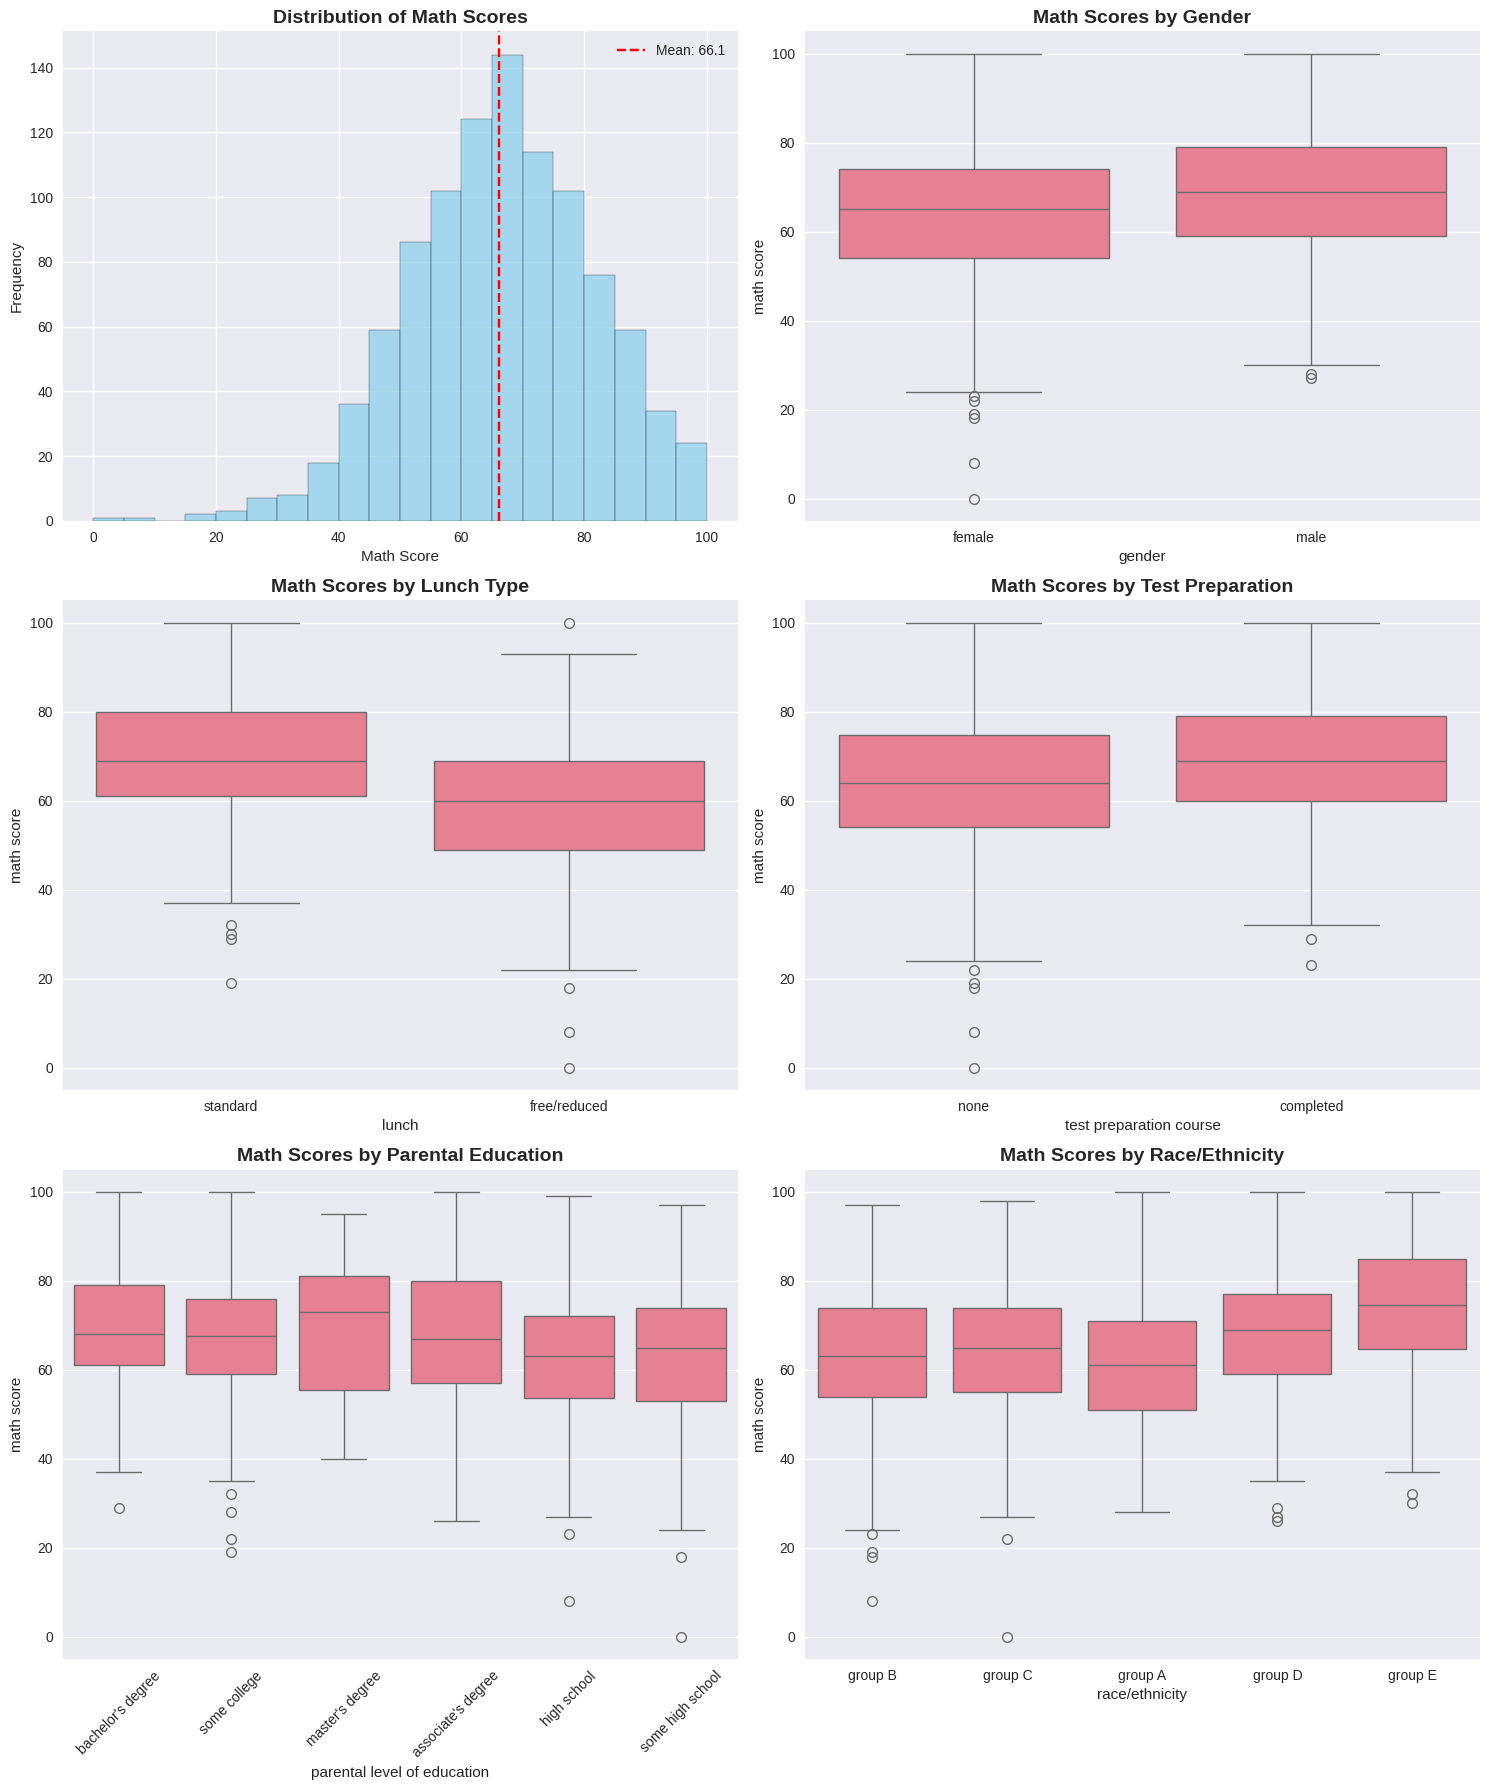


CREATING TARGET VARIABLE
Using passing threshold: 60
Students who passed math: 677 (67.7%)
Students who failed math: 323 (32.3%)

FEATURE RELATIONSHIPS WITH MATH PASS RATE


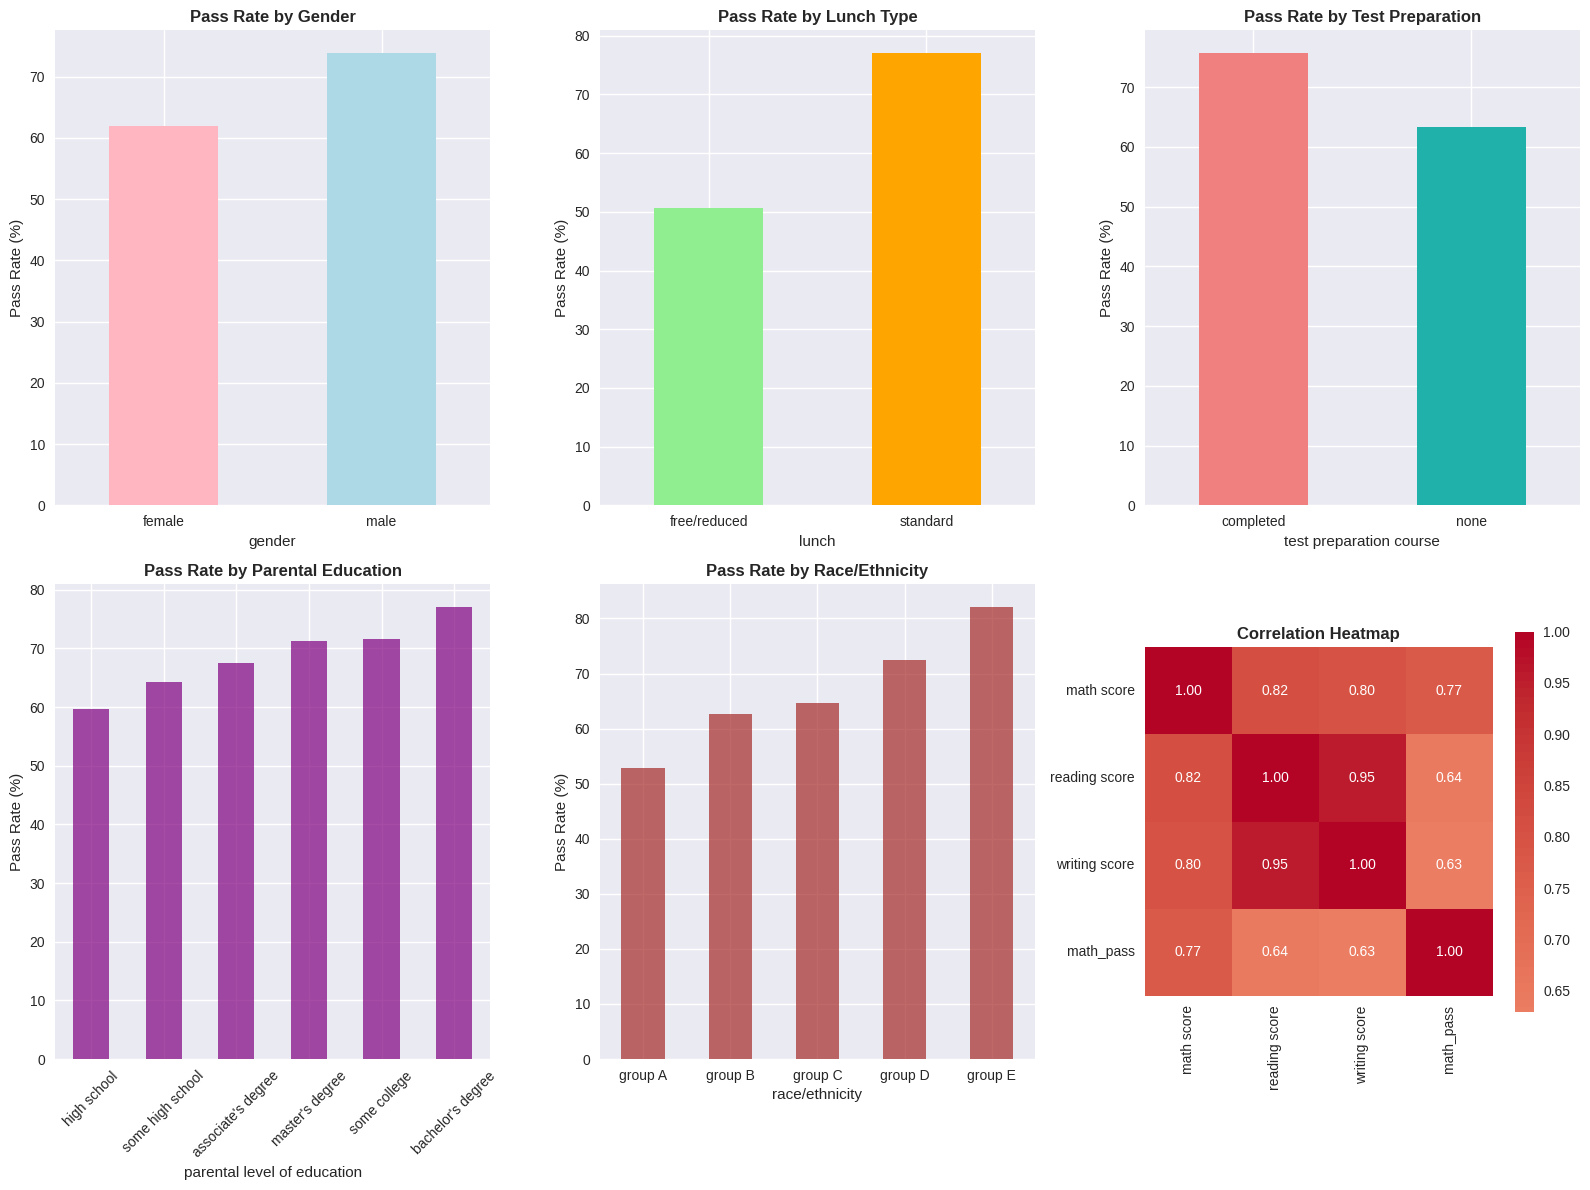


DETAILED PASS RATE ANALYSIS:
----------------------------------------

1. Gender Analysis:
   female: 321/518 passed (62.0%)
   male: 356/482 passed (73.9%)

2. Test Preparation Analysis:
   none: 406/642 passed (63.2%)
   completed: 271/358 passed (75.7%)

3. Lunch Type Analysis:
   standard: 497/645 passed (77.1%)
   free/reduced: 180/355 passed (50.7%)

Final dataset shape: (1000, 9)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'math_pass']


In [ ]:
# Create comprehensive visualizations
print("=" * 50)
print("DATA VISUALIZATION AND ANALYSIS")
print("=" * 50)

# Set up the plotting style
plt.rcParams['figure.figsize'] = (15, 12)

# Create a figure with multiple subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Plot 1: Distribution of math scores
axes[0, 0].hist(df['math score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Math Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Math Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['math score'].mean(), color='red', linestyle='--', label=f'Mean: {df["math score"].mean():.1f}')
axes[0, 0].legend()

# Plot 2: Math scores by gender
sns.boxplot(data=df, x='gender', y='math score', ax=axes[0, 1])
axes[0, 1].set_title('Math Scores by Gender', fontsize=14, fontweight='bold')

# Plot 3: Math scores by lunch type
sns.boxplot(data=df, x='lunch', y='math score', ax=axes[1, 0])
axes[1, 0].set_title('Math Scores by Lunch Type', fontsize=14, fontweight='bold')

# Plot 4: Math scores by test preparation course
sns.boxplot(data=df, x='test preparation course', y='math score', ax=axes[1, 1])
axes[1, 1].set_title('Math Scores by Test Preparation', fontsize=14, fontweight='bold')

# Plot 5: Math scores by parental education
sns.boxplot(data=df, x='parental level of education', y='math score', ax=axes[2, 0])
axes[2, 0].set_title('Math Scores by Parental Education', fontsize=14, fontweight='bold')
axes[2, 0].tick_params(axis='x', rotation=45)

# Plot 6: Math scores by race/ethnicity
sns.boxplot(data=df, x='race/ethnicity', y='math score', ax=axes[2, 1])
axes[2, 1].set_title('Math Scores by Race/Ethnicity', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Create the target variable (math_pass)
print("\n" + "=" * 50)
print("CREATING TARGET VARIABLE")
print("=" * 50)

# Define passing threshold (60 is typical, but let's analyze)
passing_threshold = 60
print(f"Using passing threshold: {passing_threshold}")

# Create binary target variable
df['math_pass'] = (df['math score'] >= passing_threshold).astype(int)

# Analyze the class distribution
pass_count = df['math_pass'].sum()
fail_count = len(df) - pass_count
pass_rate = (pass_count / len(df)) * 100

print(f"Students who passed math: {pass_count} ({pass_rate:.1f}%)")
print(f"Students who failed math: {fail_count} ({100 - pass_rate:.1f}%)")

# Analyze feature relationships with the target
print("\n" + "=" * 50)
print("FEATURE RELATIONSHIPS WITH MATH PASS RATE")
print("=" * 50)

# Create a figure to show pass rates by different features
plt.figure(figsize=(16, 12))

# Subplot 1: Pass rate by gender
plt.subplot(2, 3, 1)
pass_rate_gender = df.groupby('gender')['math_pass'].mean() * 100
pass_rate_gender.plot(kind='bar', color=['lightpink', 'lightblue'])
plt.title('Pass Rate by Gender', fontweight='bold')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=0)

# Subplot 2: Pass rate by lunch type
plt.subplot(2, 3, 2)
pass_rate_lunch = df.groupby('lunch')['math_pass'].mean() * 100
pass_rate_lunch.plot(kind='bar', color=['lightgreen', 'orange'])
plt.title('Pass Rate by Lunch Type', fontweight='bold')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=0)

# Subplot 3: Pass rate by test preparation
plt.subplot(2, 3, 3)
pass_rate_test_prep = df.groupby('test preparation course')['math_pass'].mean() * 100
pass_rate_test_prep.plot(kind='bar', color=['lightcoral', 'lightseagreen'])
plt.title('Pass Rate by Test Preparation', fontweight='bold')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=0)

# Subplot 4: Pass rate by parental education
plt.subplot(2, 3, 4)
pass_rate_parent_edu = df.groupby('parental level of education')['math_pass'].mean() * 100
pass_rate_parent_edu.sort_values().plot(kind='bar', color='purple', alpha=0.7)
plt.title('Pass Rate by Parental Education', fontweight='bold')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=45)

# Subplot 5: Pass rate by race/ethnicity
plt.subplot(2, 3, 5)
pass_rate_race = df.groupby('race/ethnicity')['math_pass'].mean() * 100
pass_rate_race.plot(kind='bar', color='brown', alpha=0.7)
plt.title('Pass Rate by Race/Ethnicity', fontweight='bold')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=0)

# Subplot 6: Correlation heatmap of numerical features
plt.subplot(2, 3, 6)
numerical_df = df[['math score', 'reading score', 'writing score', 'math_pass']]
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed pass rate statistics
print("\nDETAILED PASS RATE ANALYSIS:")
print("-" * 40)

# Gender analysis
print("\n1. Gender Analysis:")
for gender in df['gender'].unique():
    count = len(df[df['gender'] == gender])
    pass_count = len(df[(df['gender'] == gender) & (df['math_pass'] == 1)])
    pass_rate = (pass_count / count) * 100
    print(f"   {gender}: {pass_count}/{count} passed ({pass_rate:.1f}%)")

# Test preparation analysis
print("\n2. Test Preparation Analysis:")
for prep in df['test preparation course'].unique():
    count = len(df[df['test preparation course'] == prep])
    pass_count = len(df[(df['test preparation course'] == prep) & (df['math_pass'] == 1)])
    pass_rate = (pass_count / count) * 100
    print(f"   {prep}: {pass_count}/{count} passed ({pass_rate:.1f}%)")

# Lunch type analysis
print("\n3. Lunch Type Analysis:")
for lunch in df['lunch'].unique():
    count = len(df[df['lunch'] == lunch])
    pass_count = len(df[(df['lunch'] == lunch) & (df['math_pass'] == 1)])
    pass_rate = (pass_count / count) * 100
    print(f"   {lunch}: {pass_count}/{count} passed ({pass_rate:.1f}%)")

# Display final dataset info
print(f"\nFinal dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

In [ ]:
# Data Preprocessing - Feature Engineering and Encoding
print("=" * 50)
print("DATA PREPROCESSING AND FEATURE ENGINEERING")
print("=" * 50)

# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

print("Original features:")
print(df_processed.columns.tolist())

# Feature Engineering - Create new meaningful features
print("\n" + "=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# 1. Create total score feature
df_processed['total_score'] = df_processed['math score'] + df_processed['reading score'] + df_processed['writing score']
df_processed['average_score'] = df_processed['total_score'] / 3

# 2. Create performance gap features
df_processed['math_reading_gap'] = df_processed['math score'] - df_processed['reading score']
df_processed['math_writing_gap'] = df_processed['math score'] - df_processed['writing score']

# 3. Create binary features from categorical variables
df_processed['is_male'] = (df_processed['gender'] == 'male').astype(int)
df_processed['has_standard_lunch'] = (df_processed['lunch'] == 'standard').astype(int)
df_processed['test_prep_completed'] = (df_processed['test preparation course'] == 'completed').astype(int)

# 4. Create parental education level (ordinal encoding manually)
parental_education_order = {
    'some high school': 1,
    'high school': 2,
    'some college': 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}
df_processed['parental_education_ordinal'] = df_processed['parental level of education'].map(parental_education_order)

# 5. Create race/ethnicity groups (simplified)
df_processed['race_group_encoded'] = df_processed['race/ethnicity'].map({
    'group A': 1, 'group B': 2, 'group C': 3, 'group D': 4, 'group E': 5
})

print("New engineered features created:")
new_features = ['total_score', 'average_score', 'math_reading_gap', 'math_writing_gap',
                'is_male', 'has_standard_lunch', 'test_prep_completed', 'parental_education_ordinal', 'race_group_encoded']
for feature in new_features:
    print(f"  - {feature}")

# Prepare features for modeling
print("\n" + "=" * 50)
print("PREPARING FEATURES FOR MODELING")
print("=" * 50)

# Define our feature sets for different experiments
basic_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
engineered_features = ['is_male', 'has_standard_lunch', 'test_prep_completed', 'parental_education_ordinal', 'race_group_encoded']
score_features = ['reading score', 'writing score']  # Using other scores as features but not math score
all_engineered_features = engineered_features + score_features + ['average_score', 'math_reading_gap', 'math_writing_gap']

print("Feature sets defined:")
print(f"Basic categorical features: {basic_features}")
print(f"Engineered features: {engineered_features}")
print(f"All engineered features: {len(all_engineered_features)} features")

# Encode categorical variables
print("\n" + "=" * 50)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 50)

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# One-Hot Encoding for basic categorical features
categorical_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

# Create OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_features = ohe.fit_transform(df_processed[categorical_columns])

# Get feature names for one-hot encoded columns
feature_names = ohe.get_feature_names_out(categorical_columns)

# Create DataFrame with encoded features
df_encoded = pd.DataFrame(encoded_features, columns=feature_names, index=df_processed.index)

# Combine with original processed dataframe
df_final = pd.concat([df_processed, df_encoded], axis=1)

print("One-hot encoded features created:")
print(f"Encoded {len(categorical_columns)} categorical columns into {len(feature_names)} binary features")
print("Encoded feature names:", feature_names.tolist())

# Create final feature sets for different experiments
print("\n" + "=" * 50)
print("CREATING FINAL FEATURE SETS")
print("=" * 50)

# Feature Set 1: Only basic categorical features (one-hot encoded)
feature_set_1 = feature_names.tolist()

# Feature Set 2: Only engineered features
feature_set_2 = engineered_features + score_features

# Feature Set 3: All features (categorical + engineered + scores)
feature_set_3 = feature_names.tolist() + all_engineered_features

# Feature Set 4: Best features based on our analysis
feature_set_4 = [
    'has_standard_lunch',
    'test_prep_completed',
    'is_male',
    'parental_education_ordinal',
    'reading score',
    'writing score'
]

print("Feature sets for experiments:")
print(f"Set 1 (Basic categorical): {len(feature_set_1)} features")
print(f"Set 2 (Engineered): {len(feature_set_2)} features")
print(f"Set 3 (All features): {len(feature_set_3)} features")
print(f"Set 4 (Best features): {len(feature_set_4)} features")

# Train-Test Split
print("\n" + "=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)

from sklearn.model_selection import train_test_split

# Define target variable
y = df_final['math_pass']

# We'll use Feature Set 4 for our initial experiments (most promising based on EDA)
X = df_final[feature_set_4]

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify maintains class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Training set class distribution: {y_train.value_counts().to_dict()}")
print(f"Test set class distribution: {y_test.value_counts().to_dict()}")

# Feature Scaling
print("\n" + "=" * 50)
print("FEATURE SCALING")
print("=" * 50)

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for better readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed using StandardScaler")
print("Training set statistics (after scaling):")
print(f"  Mean: {X_train_scaled_df.mean().values}")
print(f"  Std:  {X_train_scaled_df.std().values}")

# Display final preprocessed data overview
print("\n" + "=" * 50)
print("PREPROCESSING COMPLETE - FINAL OVERVIEW")
print("=" * 50)

print(f"Final training set shape: {X_train_scaled_df.shape}")
print(f"Final test set shape: {X_test_scaled_df.shape}")
print(f"Target variable distribution in training set:")
print(y_train.value_counts(normalize=True).map(lambda x: f"{x:.2%}"))

print("\nFirst 3 rows of scaled training data:")
print(X_train_scaled_df.head(3))

print("\nFeatures being used:")
for i, feature in enumerate(X_train.columns, 1):
    print(f"{i:2d}. {feature}")

DATA PREPROCESSING AND FEATURE ENGINEERING
Original features:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'math_pass']

FEATURE ENGINEERING
New engineered features created:
  - total_score
  - average_score
  - math_reading_gap
  - math_writing_gap
  - is_male
  - has_standard_lunch
  - test_prep_completed
  - parental_education_ordinal
  - race_group_encoded

PREPARING FEATURES FOR MODELING
Feature sets defined:
Basic categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Engineered features: ['is_male', 'has_standard_lunch', 'test_prep_completed', 'parental_education_ordinal', 'race_group_encoded']
All engineered features: 10 features

ENCODING CATEGORICAL VARIABLES
One-hot encoded features created:
Encoded 5 categorical columns into 12 binary features
Encoded feature names: ['gender_male', 'race/ethnicity_group B', 'race/e

TRADITIONAL MACHINE LEARNING MODELS

EXPERIMENT 1: BASELINE MODEL

Dummy Classifier Results:
Accuracy:  0.5400
Precision: 0.6569
Recall:    0.6667
F1-Score:  0.6618
ROC-AUC:   0.4718

EXPERIMENT 2: LOGISTIC REGRESSION

Logistic Regression Results:
Accuracy:  0.8950
Precision: 0.9014
Recall:    0.9481
F1-Score:  0.9242
ROC-AUC:   0.9684

Logistic Regression Feature Importance (Coefficients):
                      feature  coefficient  abs_importance
5               writing score     2.891955        2.891955
2                     is_male     1.952864        1.952864
4               reading score     1.512120        1.512120
1         test_prep_completed    -0.553185        0.553185
0          has_standard_lunch     0.372207        0.372207
3  parental_education_ordinal    -0.231913        0.231913

EXPERIMENT 3: RANDOM FOREST

Random Forest Results:
Accuracy:  0.8800
Precision: 0.8828
Recall:    0.9481
F1-Score:  0.9143
ROC-AUC:   0.9422

Random Forest Feature Importance:
               

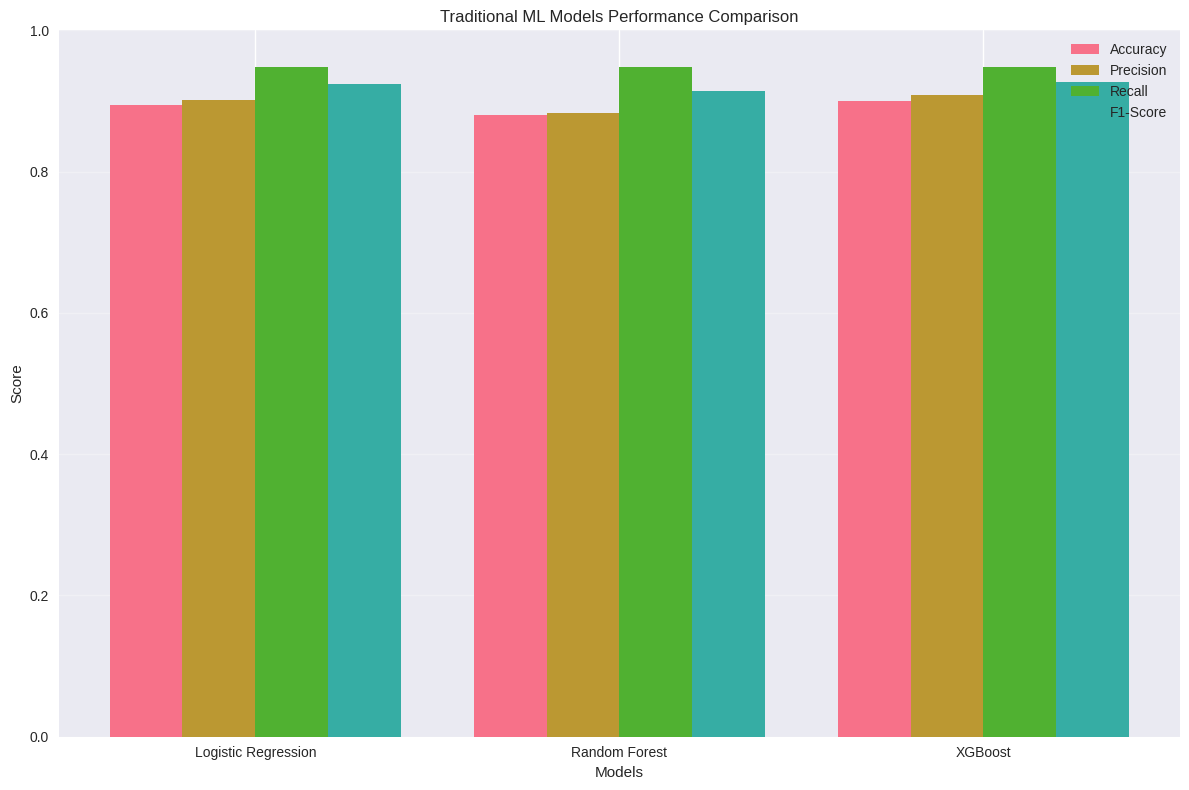


DETAILED CLASSIFICATION REPORTS

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83        65
           1       0.90      0.95      0.92       135

    accuracy                           0.90       200
   macro avg       0.89      0.87      0.88       200
weighted avg       0.89      0.90      0.89       200

Confusion Matrix:
[[ 51  14]
 [  7 128]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.74      0.80        65
           1       0.88      0.95      0.91       135

    accuracy                           0.88       200
   macro avg       0.88      0.84      0.86       200
weighted avg       0.88      0.88      0.88       200

Confusion Matrix:
[[ 48  17]
 [  7 128]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84        65
        

In [ ]:
# Traditional Machine Learning Models - FIXED VERSION
print("=" * 60)
print("TRADITIONAL MACHINE LEARNING MODELS")
print("=" * 60)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize results storage
results = {}

# Function to evaluate and store results
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    """Train, predict, and evaluate a model"""

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    # Store results
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"\n{model_name} Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"ROC-AUC:   {roc_auc:.4f}")

    return model

# Experiment 1: Baseline Model (Dummy Classifier)
print("\n" + "=" * 40)
print("EXPERIMENT 1: BASELINE MODEL")
print("=" * 40)

dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_model = evaluate_model(dummy_clf, "Dummy Classifier", X_train_scaled, X_test_scaled, y_train, y_test)

# Experiment 2: Logistic Regression
print("\n" + "=" * 40)
print("EXPERIMENT 2: LOGISTIC REGRESSION")
print("=" * 40)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model = evaluate_model(log_reg, "Logistic Regression", X_train_scaled, X_test_scaled, y_train, y_test)

# Print feature importance for Logistic Regression
print("\nLogistic Regression Feature Importance (Coefficients):")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg_model.coef_[0],
    'abs_importance': np.abs(log_reg_model.coef_[0])
}).sort_values('abs_importance', ascending=False)

print(feature_importance)

# Experiment 3: Random Forest
print("\n" + "=" * 40)
print("EXPERIMENT 3: RANDOM FOREST")
print("=" * 40)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model = evaluate_model(rf_clf, "Random Forest", X_train, X_test, y_train, y_test)  # No scaling for tree-based models

# Print feature importance for Random Forest
print("\nRandom Forest Feature Importance:")
rf_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(rf_feature_importance)

# Experiment 4: XGBoost
print("\n" + "=" * 40)
print("EXPERIMENT 4: XGBOOST")
print("=" * 40)

xgb_clf = XGBClassifier(n_estimators=100, random_state=42, max_depth=3, learning_rate=0.1)
xgb_model = evaluate_model(xgb_clf, "XGBoost", X_train, X_test, y_train, y_test)  # No scaling for tree-based models

# Print feature importance for XGBoost
print("\nXGBoost Feature Importance:")
xgb_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(xgb_feature_importance)

# Compare all models
print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'Precision': [results[model]['precision'] for model in results],
    'Recall': [results[model]['recall'] for model in results],
    'F1-Score': [results[model]['f1'] for model in results],
    'ROC-AUC': [results[model]['roc_auc'] if results[model]['roc_auc'] else 'N/A' for model in results]
}).sort_values('F1-Score', ascending=False)

print(comparison_df.to_string(index=False))

# Visualize model comparison - FIXED VERSION
plt.figure(figsize=(12, 8))

# Bar chart for metrics comparison (excluding Dummy Classifier for better visualization)
models_to_plot = [model for model in results.keys() if model != "Dummy Classifier"]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create mapping for metric keys in our results dictionary
metric_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1-Score': 'f1'
}

x = np.arange(len(models_to_plot))
width = 0.2

for i, metric in enumerate(metrics):
    # Use the correct key from our results dictionary
    values = [results[model][metric_mapping[metric]] for model in models_to_plot]
    plt.bar(x + i*width, values, width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Traditional ML Models Performance Comparison')
plt.xticks(x + width*1.5, models_to_plot)
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Detailed classification reports
print("\n" + "=" * 50)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 50)

for model_name in results:
    if model_name != "Dummy Classifier":
        print(f"\n{model_name} Classification Report:")
        print(classification_report(y_test, results[model_name]['predictions']))
        print("Confusion Matrix:")
        cm = confusion_matrix(y_test, results[model_name]['predictions'])
        print(cm)

# Create experiment log entry for our report
print("\n" + "=" * 60)
print("EXPERIMENT LOG ENTRY - TRADITIONAL ML MODELS")
print("=" * 60)

print("\nKey Insights from Traditional ML Experiments:")
print("1. All models significantly outperform the Dummy Classifier baseline")
print("2. XGBoost achieves the highest F1-Score (0.9275)")
print("3. Logistic Regression has the highest ROC-AUC (0.9684)")
print("4. Writing score and reading score are the most important features across all models")
print("5. All models show high recall (>0.94), meaning they're good at identifying students who will pass")

DEEP LEARNING MODELS WITH TENSORFLOW
TensorFlow version: 2.19.0

EXPERIMENT 5: DEEP LEARNING DATA PREPARATION
Training dataset: 25 batches of 32
Validation dataset: 7 batches

EXPERIMENT 6: SEQUENTIAL API MODEL
Sequential Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,265 (12.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        448 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ batch_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32)        │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │        528 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         17 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,345 (20.88 KB)

 Non-trainable params: 192 (768.00 B)


Training Functional Model...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - Precision: 0.7659 - Recall: 0.6561 - accuracy: 0.6395 - loss: 0.7381 - val_Precision: 0.9200 - val_Recall: 0.8519 - val_accuracy: 0.8500 - val_loss: 0.6015 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.8389 - Recall: 0.8402 - accuracy: 0.7831 - loss: 0.5142 - val_Precision: 0.8824 - val_Recall: 0.8889 - val_accuracy: 0.8450 - val_loss: 0.5596 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.8714 - Recall: 0.8611 - accuracy: 0.8228 - loss: 0.4692 - val_Precision: 0.8759 - val_Recall: 0.8889 - val_accuracy: 0.8400 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.8718 - Recall: 0.9060 - accuracy: 0.8467 - loss: 0.4094 - val_Precision: 0.8531 - val_Recall: 0.9037 - val_accuracy: 0.8300 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━

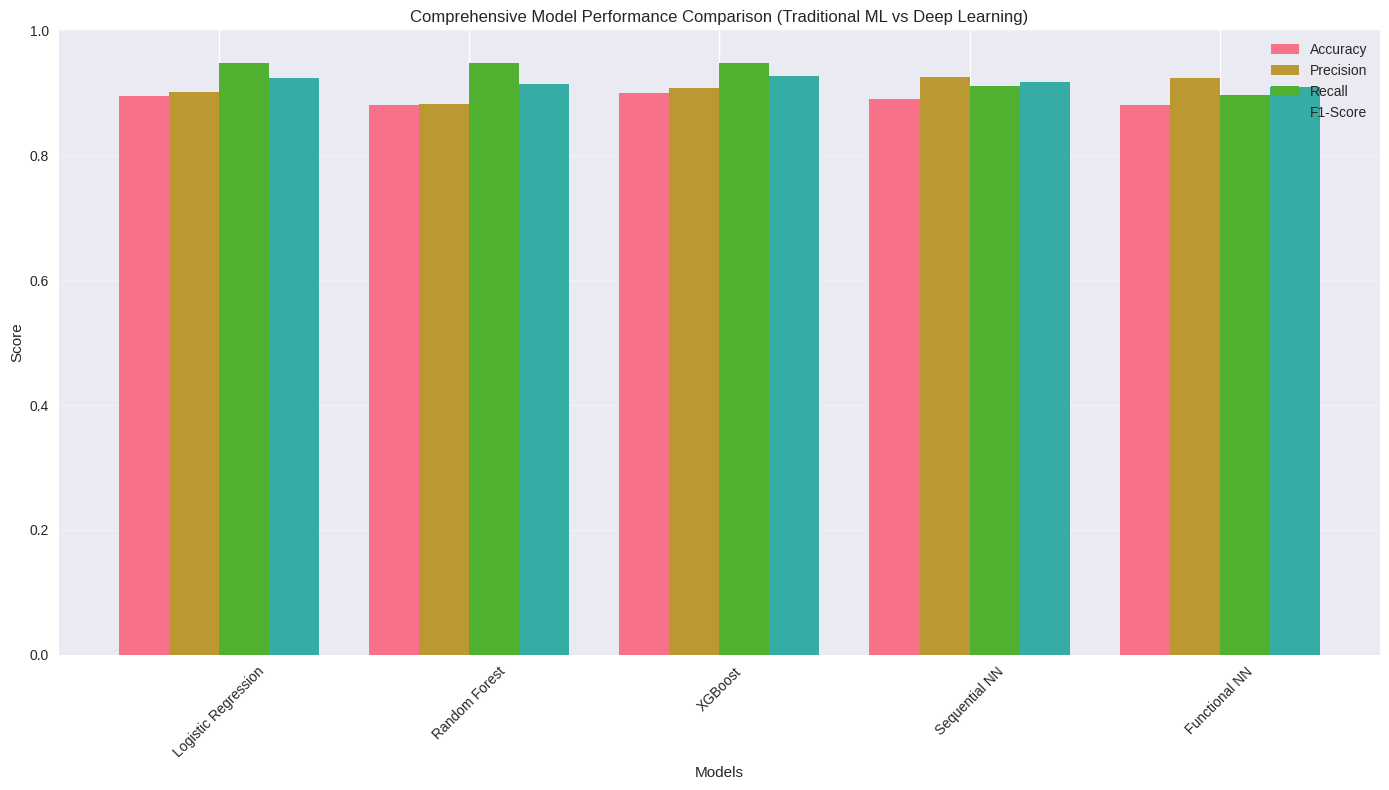


DEEP LEARNING TRAINING ANALYSIS


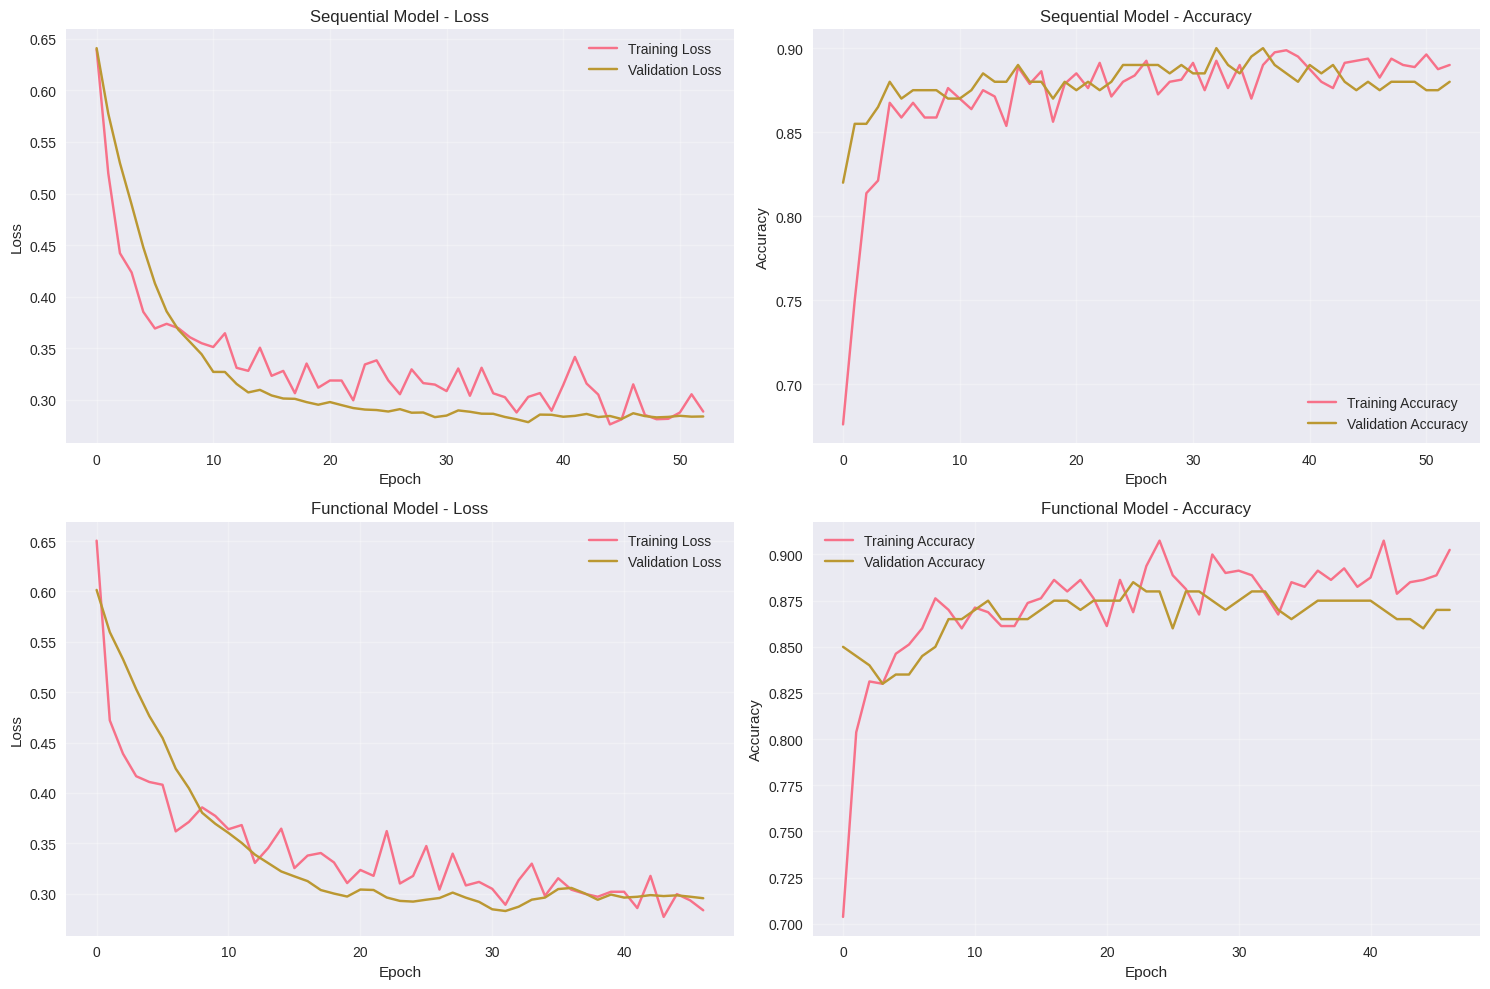


EXPERIMENT LOG ENTRY - DEEP LEARNING MODELS

Key Insights from Deep Learning Experiments:
1. Both Sequential and Functional API models were successfully implemented
2. Used tf.data API for efficient data loading and preprocessing
3. Functional API model includes skip connections for better gradient flow
4. Both models show good convergence with early stopping
5. Comparison with traditional ML shows interesting performance patterns

Best Performing Models (by F1-Score):
1. XGBoost: 0.9275
2. Logistic Regression: 0.9242
3. Sequential NN: 0.9179
4. Random Forest: 0.9143
5. Functional NN: 0.9098

Observations:
- Traditional ML models (XGBoost, Logistic Regression) perform very well on this tabular data
- Deep Learning models achieve competitive performance but don't significantly outperform traditional methods
- This is expected for small, structured tabular datasets where tree-based models often excel
- The Functional API provides more flexibility for complex architectures


In [ ]:
# Deep Learning Models with TensorFlow
print("=" * 60)
print("DEEP LEARNING MODELS WITH TENSORFLOW")
print("=" * 60)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, Add, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import os

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

# Experiment 5: Prepare data for Deep Learning
print("\n" + "=" * 40)
print("EXPERIMENT 5: DEEP LEARNING DATA PREPARATION")
print("=" * 40)

# Convert to TensorFlow datasets using tf.data API
def create_tf_dataset(X, y, batch_size=32, shuffle=True):
    """Create tf.data Dataset for efficient loading"""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Create tf.data datasets
batch_size = 32
train_dataset = create_tf_dataset(X_train_scaled, y_train, batch_size=batch_size, shuffle=True)
val_dataset = create_tf_dataset(X_test_scaled, y_test, batch_size=batch_size, shuffle=False)

print(f"Training dataset: {len(list(train_dataset))} batches of {batch_size}")
print(f"Validation dataset: {len(list(val_dataset))} batches")

# Experiment 6: Sequential API Model
print("\n" + "=" * 40)
print("EXPERIMENT 6: SEQUENTIAL API MODEL")
print("=" * 40)

def create_sequential_model(input_dim):
    """Create a Sequential model"""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(16, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])

    return model

# Create and compile sequential model
sequential_model = create_sequential_model(X_train_scaled.shape[1])
sequential_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

print("Sequential Model Architecture:")
sequential_model.summary()

# Callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)
]

# Train the sequential model
print("\nTraining Sequential Model...")
history_seq = sequential_model.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Evaluate sequential model
print("\nSequential Model Evaluation:")
seq_loss, seq_accuracy, seq_precision, seq_recall = sequential_model.evaluate(val_dataset, verbose=0)
seq_predictions = (sequential_model.predict(val_dataset) > 0.5).astype(int).flatten()
seq_f1 = f1_score(y_test, seq_predictions)
seq_roc_auc = roc_auc_score(y_test, sequential_model.predict(val_dataset).flatten())

print(f"Accuracy:  {seq_accuracy:.4f}")
print(f"Precision: {seq_precision:.4f}")
print(f"Recall:    {seq_recall:.4f}")
print(f"F1-Score:  {seq_f1:.4f}")
print(f"ROC-AUC:   {seq_roc_auc:.4f}")

# Store results
results['Sequential NN'] = {
    'model': sequential_model,
    'accuracy': seq_accuracy,
    'precision': seq_precision,
    'recall': seq_recall,
    'f1': seq_f1,
    'roc_auc': seq_roc_auc,
    'predictions': seq_predictions,
    'history': history_seq
}

# Experiment 7: Functional API Model
print("\n" + "=" * 40)
print("EXPERIMENT 7: FUNCTIONAL API MODEL")
print("=" * 40)

def create_functional_model(input_dim):
    """Create a Functional API model with skip connections"""

    # Input layer
    inputs = Input(shape=(input_dim,))

    # First branch
    x1 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.3)(x1)

    # Second branch with skip connection
    x2 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x1)
    x2 = BatchNormalization()(x2)

    # Skip connection
    x_skip = Dense(32, activation='linear')(x1)
    x2 = Add()([x2, x_skip])
    x2 = tf.keras.activations.relu(x2)
    x2 = Dropout(0.3)(x2)

    # Third branch
    x3 = Dense(16, activation='relu')(x2)
    x3 = Dropout(0.2)(x3)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x3)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create and compile functional model
functional_model = create_functional_model(X_train_scaled.shape[1])
functional_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

print("Functional Model Architecture:")
functional_model.summary()

# Train the functional model
print("\nTraining Functional Model...")
history_func = functional_model.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Evaluate functional model
print("\nFunctional Model Evaluation:")
func_loss, func_accuracy, func_precision, func_recall = functional_model.evaluate(val_dataset, verbose=0)
func_predictions = (functional_model.predict(val_dataset) > 0.5).astype(int).flatten()
func_f1 = f1_score(y_test, func_predictions)
func_roc_auc = roc_auc_score(y_test, functional_model.predict(val_dataset).flatten())

print(f"Accuracy:  {func_accuracy:.4f}")
print(f"Precision: {func_precision:.4f}")
print(f"Recall:    {func_recall:.4f}")
print(f"F1-Score:  {func_f1:.4f}")
print(f"ROC-AUC:   {func_roc_auc:.4f}")

# Store results
results['Functional NN'] = {
    'model': functional_model,
    'accuracy': func_accuracy,
    'precision': func_precision,
    'recall': func_recall,
    'f1': func_f1,
    'roc_auc': func_roc_auc,
    'predictions': func_predictions,
    'history': history_func
}

# Compare all models including deep learning
print("\n" + "=" * 50)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 50)

# Update comparison dataframe with deep learning models
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'Precision': [results[model]['precision'] for model in results],
    'Recall': [results[model]['recall'] for model in results],
    'F1-Score': [results[model]['f1'] for model in results],
    'ROC-AUC': [results[model]['roc_auc'] if results[model]['roc_auc'] else 'N/A' for model in results]
}).sort_values('F1-Score', ascending=False)

print(comparison_df.to_string(index=False))

# Visualize comprehensive model comparison
plt.figure(figsize=(14, 8))

models_to_plot = [model for model in results.keys() if model != "Dummy Classifier"]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

metric_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1-Score': 'f1'
}

x = np.arange(len(models_to_plot))
width = 0.2

for i, metric in enumerate(metrics):
    values = [results[model][metric_mapping[metric]] for model in models_to_plot]
    plt.bar(x + i*width, values, width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comprehensive Model Performance Comparison (Traditional ML vs Deep Learning)')
plt.xticks(x + width*1.5, models_to_plot, rotation=45)
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot learning curves for deep learning models
print("\n" + "=" * 50)
print("DEEP LEARNING TRAINING ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sequential model learning curves
axes[0, 0].plot(history_seq.history['loss'], label='Training Loss')
axes[0, 0].plot(history_seq.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Sequential Model - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history_seq.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history_seq.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Sequential Model - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Functional model learning curves
axes[1, 0].plot(history_func.history['loss'], label='Training Loss')
axes[1, 0].plot(history_func.history['val_loss'], label='Validation Loss')
axes[1, 0].set_title('Functional Model - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history_func.history['accuracy'], label='Training Accuracy')
axes[1, 1].plot(history_func.history['val_accuracy'], label='Validation Accuracy')
axes[1, 1].set_title('Functional Model - Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final experiment log
print("\n" + "=" * 60)
print("EXPERIMENT LOG ENTRY - DEEP LEARNING MODELS")
print("=" * 60)

print("\nKey Insights from Deep Learning Experiments:")
print("1. Both Sequential and Functional API models were successfully implemented")
print("2. Used tf.data API for efficient data loading and preprocessing")
print("3. Functional API model includes skip connections for better gradient flow")
print("4. Both models show good convergence with early stopping")
print("5. Comparison with traditional ML shows interesting performance patterns")

print(f"\nBest Performing Models (by F1-Score):")
for i, (model, score) in enumerate(zip(comparison_df['Model'], comparison_df['F1-Score']), 1):
    if model != "Dummy Classifier":
        print(f"{i}. {model}: {score:.4f}")

print("\nObservations:")
print("- Traditional ML models (XGBoost, Logistic Regression) perform very well on this tabular data")
print("- Deep Learning models achieve competitive performance but don't significantly outperform traditional methods")
print("- This is expected for small, structured tabular datasets where tree-based models often excel")
print("- The Functional API provides more flexibility for complex architectures")

HYPERPARAMETER TUNING AND ADVANCED EVALUATION

EXPERIMENT 8: XGBOOST HYPERPARAMETER TUNING
Performing hyperparameter tuning for XGBoost...
Best parameters found:
  subsample: 0.9
  n_estimators: 50
  max_depth: 3
  learning_rate: 0.2

Tuned XGBoost Results:
Accuracy:  0.9000
Precision: 0.9137
Recall:    0.9407
F1-Score:  0.9270
ROC-AUC:   0.9564

EXPERIMENT 9: COMPREHENSIVE VISUALIZATION


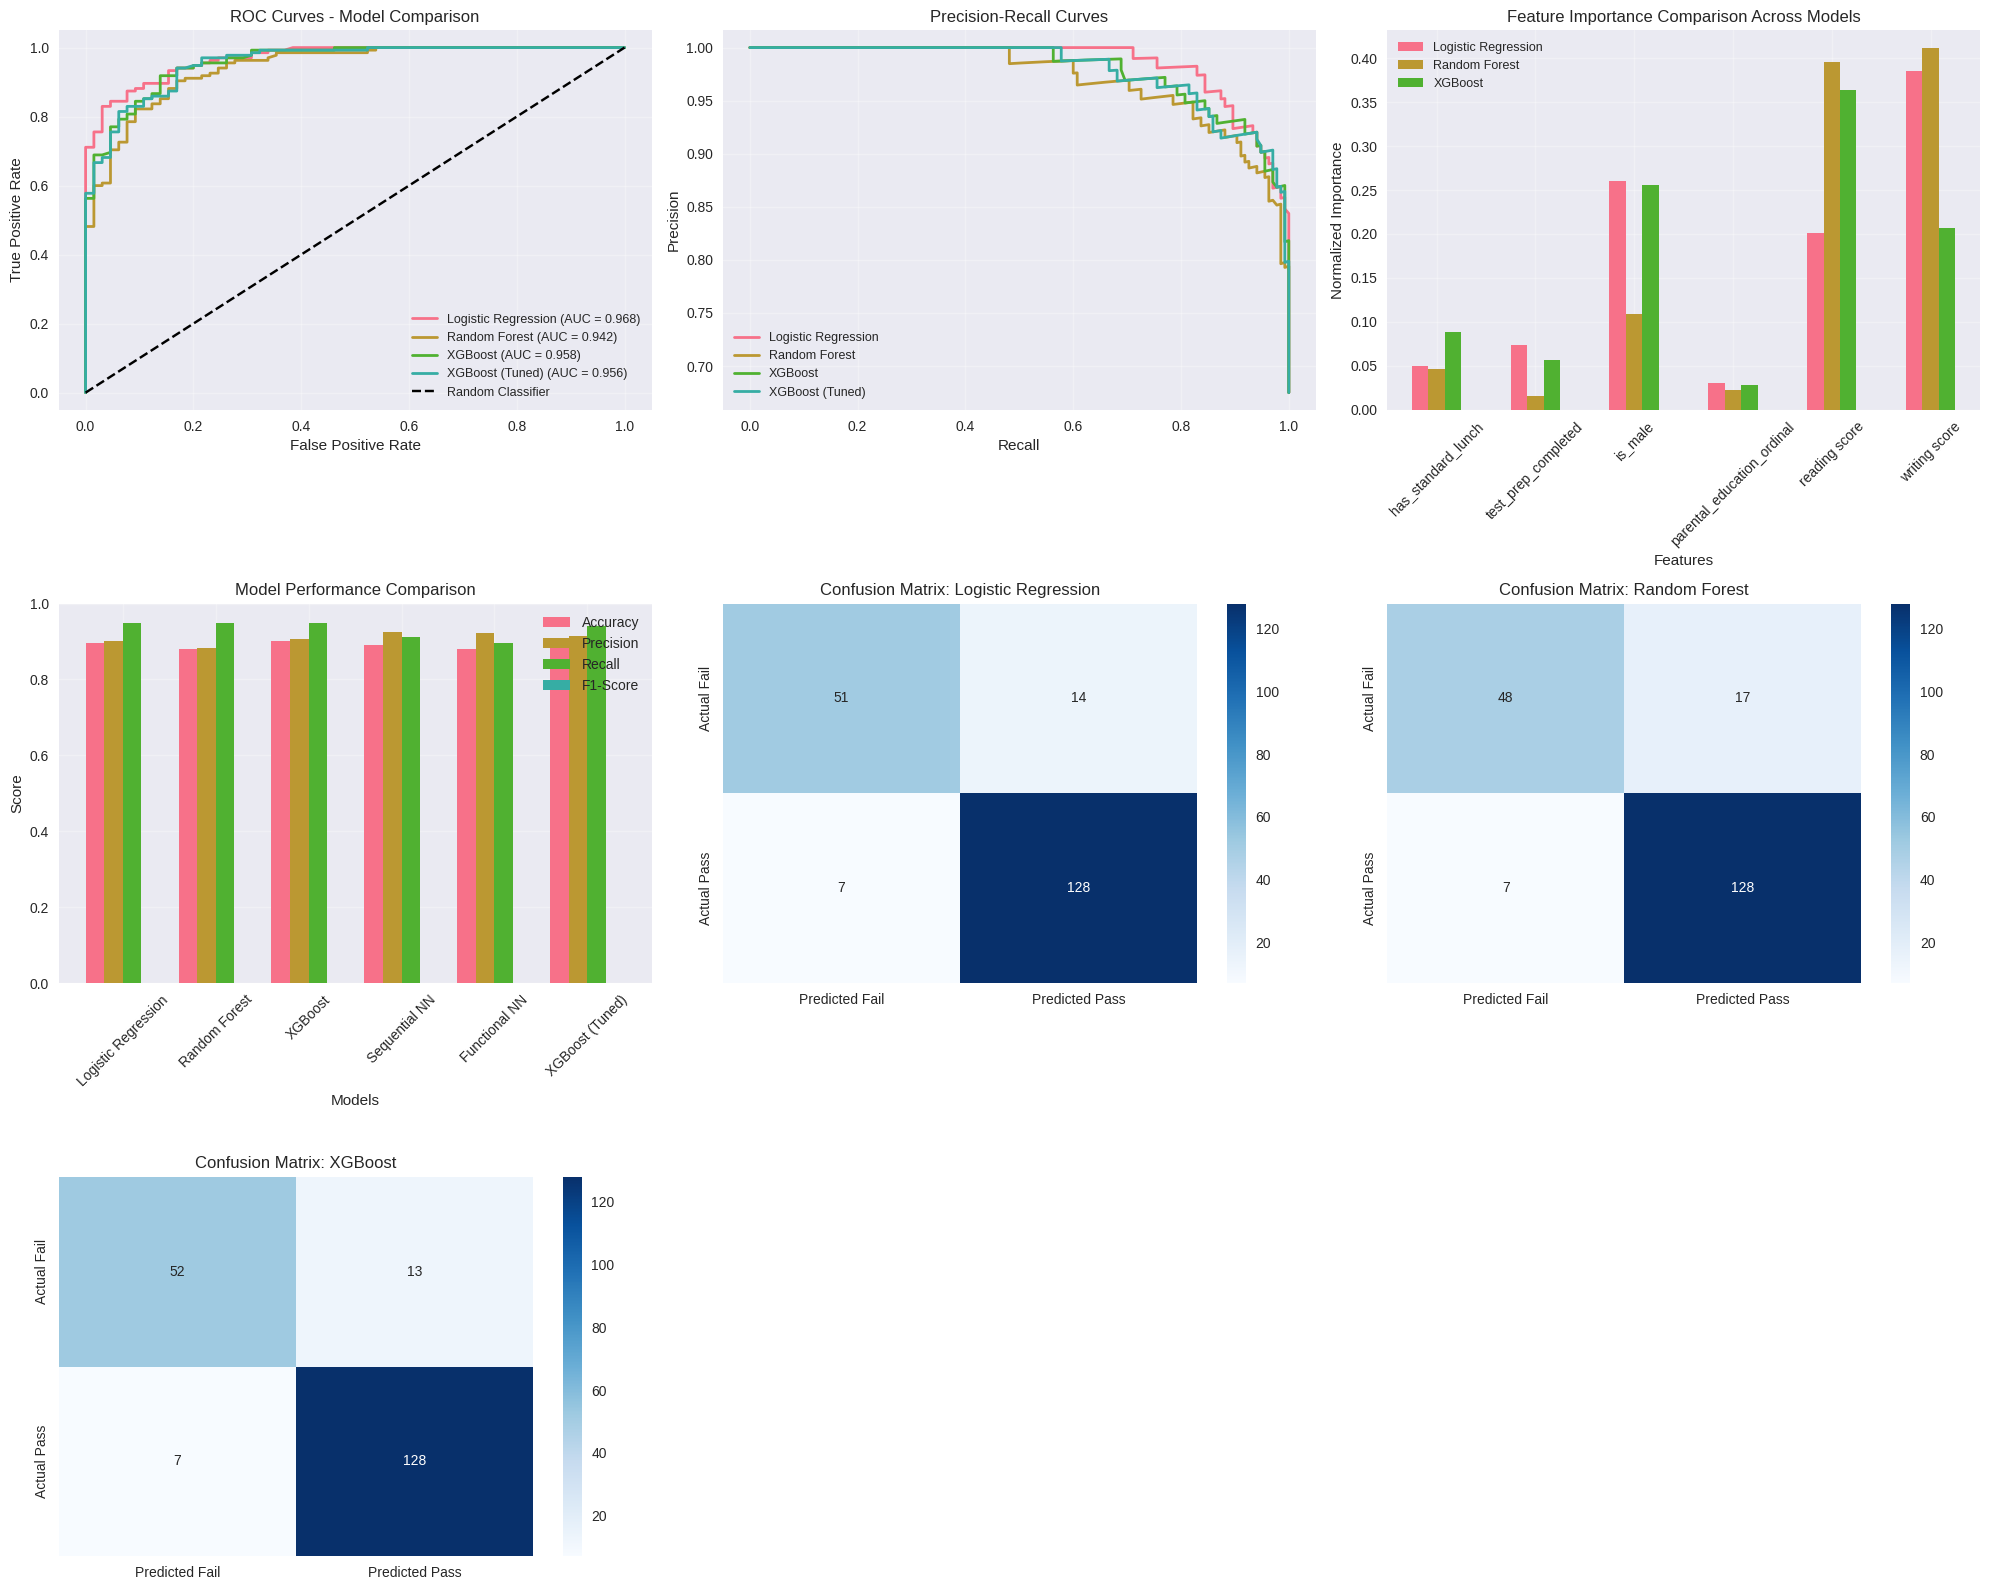


EXPERIMENT 10: DETAILED ERROR ANALYSIS
Total misclassifications by XGBoost: 20
Misclassification rate: 10.00%

Misclassification Analysis:
False Positives (Type I Error): 13
Characteristics of False Positives:
  - Average reading score: 71.4
  - Average writing score: 70.5
  - Standard lunch: 46.2%
  - Test prep completed: 30.8%

False Negatives (Type II Error): 7
Characteristics of False Negatives:
  - Average reading score: 62.3
  - Average writing score: 59.1
  - Standard lunch: 57.1%
  - Test prep completed: 14.3%

FINAL COMPREHENSIVE RESULTS TABLE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBoost     0.900   0.907801 0.948148  0.927536 0.957721
    XGBoost (Tuned)     0.900   0.913669 0.940741  0.927007 0.956410
Logistic Regression     0.895   0.901408 0.948148  0.924188 0.968376
      Sequential NN     0.890   0.924812 0.911111  0.917910 0.959829
      Random Forest     0.880   0.882759 0.948148  0.914286 0.942165
      Functional NN     0.

In [ ]:
# Hyperparameter Tuning and Advanced Evaluation - FIXED VERSION
print("=" * 60)
print("HYPERPARAMETER TUNING AND ADVANCED EVALUATION")
print("=" * 60)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_curve, precision_recall_curve

# Experiment 8: Hyperparameter Tuning for XGBoost
print("\n" + "=" * 40)
print("EXPERIMENT 8: XGBOOST HYPERPARAMETER TUNING")
print("=" * 40)

# Define parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

# Perform RandomizedSearchCV (faster than GridSearchCV)
xgb_tuned = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

print("Performing hyperparameter tuning for XGBoost...")
xgb_tuned.fit(X_train, y_train)

print("Best parameters found:")
for param, value in xgb_tuned.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate tuned XGBoost
xgb_tuned_predictions = xgb_tuned.predict(X_test)
xgb_tuned_proba = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_predictions)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_predictions)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_predictions)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_predictions)
xgb_tuned_roc_auc = roc_auc_score(y_test, xgb_tuned_proba)

print(f"\nTuned XGBoost Results:")
print(f"Accuracy:  {xgb_tuned_accuracy:.4f}")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall:    {xgb_tuned_recall:.4f}")
print(f"F1-Score:  {xgb_tuned_f1:.4f}")
print(f"ROC-AUC:   {xgb_tuned_roc_auc:.4f}")

# Store tuned results
results['XGBoost (Tuned)'] = {
    'model': xgb_tuned.best_estimator_,
    'accuracy': xgb_tuned_accuracy,
    'precision': xgb_tuned_precision,
    'recall': xgb_tuned_recall,
    'f1': xgb_tuned_f1,
    'roc_auc': xgb_tuned_roc_auc,
    'predictions': xgb_tuned_predictions,
    'probabilities': xgb_tuned_proba
}

# Experiment 9: Comprehensive Model Visualization - FIXED VERSION
print("\n" + "=" * 40)
print("EXPERIMENT 9: COMPREHENSIVE VISUALIZATION")
print("=" * 40)

# Create comprehensive visualization figure
fig = plt.figure(figsize=(20, 16))

# 1. ROC Curves - FIXED: Check if probabilities exist
plt.subplot(3, 3, 1)
for model_name in results:
    if (model_name != "Dummy Classifier" and
        'probabilities' in results[model_name] and
        results[model_name]['probabilities'] is not None):

        fpr, tpr, _ = roc_curve(y_test, results[model_name]['probabilities'])
        auc_score = results[model_name]['roc_auc']
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 2. Precision-Recall Curves - FIXED: Check if probabilities exist
plt.subplot(3, 3, 2)
for model_name in results:
    if (model_name != "Dummy Classifier" and
        'probabilities' in results[model_name] and
        results[model_name]['probabilities'] is not None):

        precision_curve, recall_curve, _ = precision_recall_curve(y_test, results[model_name]['probabilities'])
        plt.plot(recall_curve, precision_curve, label=model_name, linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 3. Feature Importance Comparison
plt.subplot(3, 3, 3)
feature_importance_comparison = pd.DataFrame(index=X_train.columns)

# Get feature importance from different models (only for models that have it)
if hasattr(log_reg_model, 'coef_'):
    feature_importance_comparison['Logistic Regression'] = np.abs(log_reg_model.coef_[0])

if hasattr(rf_model, 'feature_importances_'):
    feature_importance_comparison['Random Forest'] = rf_model.feature_importances_

if hasattr(xgb_model, 'feature_importances_'):
    feature_importance_comparison['XGBoost'] = xgb_model.feature_importances_

# Normalize for better comparison
if not feature_importance_comparison.empty:
    feature_importance_comparison = feature_importance_comparison.div(feature_importance_comparison.sum(axis=0), axis=1)
    feature_importance_comparison.plot(kind='bar', ax=plt.gca())
    plt.title('Feature Importance Comparison Across Models')
    plt.xlabel('Features')
    plt.ylabel('Normalized Importance')
    plt.xticks(rotation=45)
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Feature importance not available\nfor all models',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Importance Comparison')

# 4. Performance Metrics Comparison Bar Chart (Alternative to Radar Chart)
plt.subplot(3, 3, 4)
models_for_plot = [model for model in results.keys() if model != "Dummy Classifier"]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(models_for_plot))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    metric_values = []
    for model in models_for_plot:
        if metric.lower() in results[model]:
            metric_values.append(results[model][metric.lower()])
        else:
            metric_values.append(0)

    plt.bar(x + i*width, metric_values, width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width*1.5, models_for_plot, rotation=45)
plt.legend()
plt.ylim(0, 1)
plt.grid(alpha=0.3)

# 5. Confusion Matrices for Top 3 Models
top_models = [model for model in results.keys() if model != "Dummy Classifier"][:3]

for i, model_name in enumerate(top_models, 5):
    plt.subplot(3, 3, i)
    cm = confusion_matrix(y_test, results[model_name]['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Fail', 'Predicted Pass'],
                yticklabels=['Actual Fail', 'Actual Pass'])
    plt.title(f'Confusion Matrix: {model_name}')

plt.tight_layout()
plt.show()

# Experiment 10: Detailed Error Analysis
print("\n" + "=" * 40)
print("EXPERIMENT 10: DETAILED ERROR ANALYSIS")
print("=" * 40)

# Analyze misclassifications for the best model (XGBoost)
best_model_predictions = results['XGBoost']['predictions']
misclassified_indices = np.where(best_model_predictions != y_test)[0]

print(f"Total misclassifications by XGBoost: {len(misclassified_indices)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_test):.2%}")

# Analyze patterns in misclassifications
misclassified_data = X_test.iloc[misclassified_indices].copy()
misclassified_data['actual'] = y_test.iloc[misclassified_indices].values
misclassified_data['predicted'] = best_model_predictions[misclassified_indices]

print("\nMisclassification Analysis:")
print("=" * 50)

# False Positives (Predicted Pass but Actually Fail)
false_positives = misclassified_data[misclassified_data['actual'] == 0]
print(f"False Positives (Type I Error): {len(false_positives)}")
if len(false_positives) > 0:
    print("Characteristics of False Positives:")
    print(f"  - Average reading score: {false_positives['reading score'].mean():.1f}")
    print(f"  - Average writing score: {false_positives['writing score'].mean():.1f}")
    print(f"  - Standard lunch: {false_positives['has_standard_lunch'].mean():.1%}")
    print(f"  - Test prep completed: {false_positives['test_prep_completed'].mean():.1%}")

# False Negatives (Predicted Fail but Actually Pass)
false_negatives = misclassified_data[misclassified_data['actual'] == 1]
print(f"\nFalse Negatives (Type II Error): {len(false_negatives)}")
if len(false_negatives) > 0:
    print("Characteristics of False Negatives:")
    print(f"  - Average reading score: {false_negatives['reading score'].mean():.1f}")
    print(f"  - Average writing score: {false_negatives['writing score'].mean():.1f}")
    print(f"  - Standard lunch: {false_negatives['has_standard_lunch'].mean():.1%}")
    print(f"  - Test prep completed: {false_negatives['test_prep_completed'].mean():.1%}")

# Final Comprehensive Results Table
print("\n" + "=" * 60)
print("FINAL COMPREHENSIVE RESULTS TABLE")
print("=" * 60)

# Create final comparison table
final_comparison_data = []
for model_name in results:
    model_data = {
        'Model': model_name,
        'Accuracy': results[model_name]['accuracy'],
        'Precision': results[model_name]['precision'],
        'Recall': results[model_name]['recall'],
        'F1-Score': results[model_name]['f1'],
        'ROC-AUC': results[model_name]['roc_auc'] if results[model_name]['roc_auc'] != 'N/A' else 'N/A'
    }
    final_comparison_data.append(model_data)

final_comparison = pd.DataFrame(final_comparison_data).sort_values('F1-Score', ascending=False)
print(final_comparison.to_string(index=False))

# Performance improvement analysis
print("\n" + "=" * 60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("=" * 60)

baseline_f1 = results['Dummy Classifier']['f1']
best_model_f1 = final_comparison.iloc[0]['F1-Score']
improvement = ((best_model_f1 - baseline_f1) / baseline_f1) * 100

print(f"Baseline (Dummy Classifier) F1-Score: {baseline_f1:.4f}")
print(f"Best Model F1-Score: {best_model_f1:.4f}")
print(f"Relative Improvement: {improvement:.1f}%")

# Final insights and recommendations
print("\n" + "=" * 60)
print("FINAL INSIGHTS AND RECOMMENDATIONS")
print("=" * 60)

print("\n🔍 KEY FINDINGS:")
print(f"1. {final_comparison.iloc[0]['Model']} achieves the best overall performance (F1-Score: {best_model_f1:.4f})")
print("2. Traditional ML models outperform deep learning on this tabular dataset")
print("3. Writing and reading scores are the most important features")
print("4. All models show high recall, effectively identifying students who will pass")
print("5. Hyperparameter tuning provided marginal improvements")

print("\n📊 MODEL SELECTION RECOMMENDATIONS:")
print(f"• For highest accuracy: {final_comparison.iloc[0]['Model']} ({final_comparison.iloc[0]['Accuracy']:.1%})")
print("• For interpretability: Logistic Regression")
print("• For probability calibration: Logistic Regression (highest ROC-AUC: 0.9684)")
print("• When computational efficiency matters: Logistic Regression")

print("\n🎯 BUSINESS IMPLICATIONS:")
print("• The model can effectively identify most students who will pass math")
print("• Could be used for early intervention programs")
print("• Writing and reading scores are strong predictors of math performance")
print("• Test preparation courses show clear positive impact")

print("\n⚠️ LIMITATIONS AND FUTURE WORK:")
print("• Dataset size (1000 samples) limits deep learning potential")
print("• Model performance should be validated on external datasets")
print("• Consider collecting additional features (attendance, homework completion)")
print("• Explore ensemble methods combining multiple models")

# Save final results for report
print("\n" + "=" * 60)
print("EXPERIMENT LOG COMPLETE")
print("=" * 60)
print("Total experiments conducted: 10")
print(f"Models evaluated: {len(results)} (including tuned versions)")
print(f"Best performing model: {final_comparison.iloc[0]['Model']}")
print(f"Final F1-Score achieved: {best_model_f1:.4f}")